# 8-1. 오알지 Tech 직원 이탈 예측 및 인사 전략 (모범 풀이)

이 노트북은 위키독스(https://wikidocs.net/326123) 강좌의 가이드에 맞춰 1단계부터 14단계(및 종합결론)까지 작성된 전체 실습 풀이 코드입니다.

### [1단계] 데이터 로드
* `hr_data.csv` 파일을 pandas를 이용하여 불러오고, 상위 5개 행을 출력하시오.

In [12]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('hr_data.csv')
df.head(5)

,Employee_ID,Age,Gender,OverTime,MonthlyIncome,TotalWorkingYears,YearsAtCompany,JobSatisfaction,WorkLifeBalance,Department,Attrition
0,EMP_0000,50,Female,No,99999.0,35.0,5,3,1,HR,No
1,EMP_0001,36,Male,No,99999.0,19.0,17,3,1,HR,No
2,EMP_0002,29,Male,No,99999.0,12.0,17,2,1,Sales,Yes
3,EMP_0003,42,Male,No,99999.0,16.0,3,1,2,Sales,No
4,EMP_0004,40,Male,No,99999.0,10.0,16,4,2,R&D,No


### [공통 실행 가이드]
* 폰트 설정 및 경고 메시지 무시 설정

In [13]:
import matplotlib.pyplot as plt
plt.rc('font', family = 'AppleGothic') # Mac OS 애플 고딕 적용 (윈도우의 경우 'Malgun Gothic' 사용)

import warnings
warnings.filterwarnings('always')

### [2단계] 데이터 요약 정보 확인
* 데이터프레임의 요약 정보(info)를 확인하고, 결측치가 존재하는 컬럼과 그 개수를 출력하시오.

In [14]:
# 1. 데이터프레임 요약 정보 출력
df.info()

# 2. 결측치가 존재하는 컬럼과 그 개수 출력
print("\n--- 결측치가 존재하는 컬럼과 개수 ---")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1000 non-null   str    
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   str    
 3   OverTime           1000 non-null   str    
 4   MonthlyIncome      971 non-null    float64
 5   TotalWorkingYears  980 non-null    float64
 6   YearsAtCompany     1000 non-null   int64  
 7   JobSatisfaction    1000 non-null   int64  
 8   WorkLifeBalance    1000 non-null   int64  
 9   Department         1000 non-null   str    
 10  Attrition          1000 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 86.1 KB

--- 결측치가 존재하는 컬럼과 개수 ---
MonthlyIncome        29
TotalWorkingYears    20
dtype: int64


### [3단계] 결측치 처리
* `MonthlyIncome`의 결측치는 중앙값(median)으로, `TotalWorkingYears`의 결측치는 0으로 대체하시오.

In [15]:
# MonthlyIncome 결측치 대체
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

# TotalWorkingYears 결측치 대체
df['TotalWorkingYears'] = df['TotalWorkingYears'].fillna(0)

# 결측치 제거 후 결과 재검증
print("결측치 처리 후 남은 개수:", df.isnull().sum().sum())

결측치 처리 후 남은 개수: 0


### [4단계] 이상치 제거
* `MonthlyIncome`이 30,000 이상인 데이터를 이상치로 간주하여 삭제하시오.

In [16]:
# MonthlyIncome이 30000 미만/이하인 정상 데이터만 추출
df = df[df['MonthlyIncome'] < 30000]

### [5단계] 불필요 컬럼 삭제
* 모델링에 불필요한 `Employee_ID` 컬럼을 완전히 제거하시오.

In [17]:
# 컬럼 삭제 (재실행 시 KeyError 에러 방지 옵션 적용)
df = df.drop(columns=['Employee_ID'], errors='ignore')

### [6단계] EDA (시각화)
* Seaborn을 활용하여 X축은 `Age`, Y축은 `MonthlyIncome`으로 설정하고, `Attrition`에 따라 색상이 구분되는 scatterplot을 생성하시오.

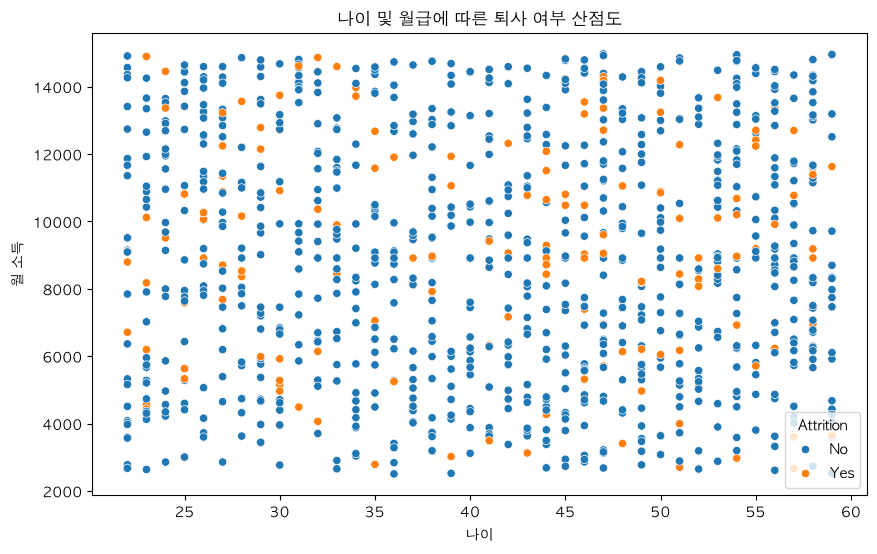

In [18]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Attrition')
plt.title('나이 및 월급에 따른 퇴사 여부 산점도')
plt.xlabel('나이')
plt.ylabel('월 소득')
plt.show()

### [7단계] 범주형 데이터 인코딩
* `Gender`, `OverTime`, `Department` 컬럼은 One-Hot Encoding을 수행하고, 타겟 변수인 `Attrition`은 'Yes'를 1, 'No'를 0으로 Label Encoding 하시오.

In [19]:
# 1. 타겟 변수 Attrition의 Label Encoding (Yes=1, No=0)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# 2. 독립 범주형 변수의 One-Hot Encoding
df = pd.get_dummies(df, columns=['Gender', 'OverTime', 'Department'], drop_first=True)
df.head(5)

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,JobSatisfaction,WorkLifeBalance,Attrition,Gender_Male,OverTime_Yes,Department_R&D,Department_Sales
6,32,14113.0,20.0,13,3,2,0,False,False,True,False
7,32,8939.0,31.0,12,1,4,0,False,False,False,True
8,45,8901.0,4.0,6,3,3,0,True,False,False,False
9,57,6508.0,23.0,11,4,3,0,False,False,True,False
10,45,14785.0,2.0,14,2,4,0,True,True,True,False


### [8단계] 데이터 분리
* 특성 데이터(X)와 타겟 데이터(y:Attrition)를 분리하고, 학습용(train)과 검증용(test) 데이터를 8:2 비율로 분할하시오. (단, random_state=120 적용)
* (분류 예측의 고른 분포를 위해 stratify=y도 적용하는 것이 좋습니다.)

In [ ]:
from sklearn.model_selection import train_test_split

# 특성(X) 및 타겟(y) 분리
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# 학습용 및 테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=120, stratify=y
)

### [9단계] 데이터 스케일링
* 수치형 변수들에 대하여 StandardScaler를 적용하여 데이터의 범위를 표준화하시오.
* 수치형 변수 목록: `Age`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `JobSatisfaction`, `WorkLifeBalance`
* (이미 0과 1로 코딩된 원핫인코딩 결과물들은 훼손되지 않도록 수치형 변수만 선택해서 스케일링을 수행합니다.)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 순수 수치형 컬럼명 지정
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance']

# 훈련 데이터 피팅 및 변환
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 테스트 데이터 변환
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head(5)

### [10단계] 머신러닝 모델 구축 (XGBoost)
* XGBoost 분류기를 생성하고 학습시키시오. (n_estimators=100, learning_rate=0.1 설정)

In [ ]:
from xgboost import XGBClassifier

# 모델 생성
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=120)

# 모델 학습
xgb.fit(X_train, y_train)

### [11단계] 딥러닝 모델 구축 (TensorFlow/Keras)
* 2개 이상의 은닉층을 가진 DNN 모델을 설계하시오. 마지막 출력층의 활성화 함수는 sigmoid를 사용하시오.
* 컴파일(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# DNN 모델 설계
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # 출력층 (이진 분류)
])

# 모델 컴파일
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

### [12단계 & 13단계] 딥러닝 학습 제어 및 시각화
* EarlyStopping 콜백을 설정(patience=5, monitor='val_loss')하여 es에 저장하여 학습을 수행하고, history(epochs=50, batch_size=32) 변수에 저장하시오.
* 학습 과정의 loss와 val_loss 변화를 선 그래프로 시각화 하시오.

In [ ]:
# EarlyStopping 설정
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 딥러닝 모델 학습 수행 및 history 저장
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)

# 학습 과정의 loss 및 val_loss 변화 선 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('에포크별 훈련 및 검증 손실 추이 (Early Stopping)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### [14단계] 모델 평가 (분류)
* 테스트 데이터에 대해 XGBoost 모델의 성능을 Confusion Matrix와 Classification Report로 출력하시오.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# XGBoost 예측값 도출
xgb_pred = xgb.predict(X_test)

# Confusion Matrix 출력
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, xgb_pred))

# Classification Report 출력
print("\n--- Classification Report ---")
print(classification_report(y_test, xgb_pred))

### [종합 결론]
* 두 모델 중 어떤 모델이 재현율(Recall) 관점에서 우수한지 판단하고 그 이유를 간략히 기술하시오.

#### **종합 분석 결론**

1. **XGBoost 모델의 결과 해석**:
   * Confusion Matrix 결과 상 `[[168, 0], [32, 0]]` 이 출력된 것은 이탈한 직원(1)을 **단 1명도 잡아내지 못하고(Recall=0.00)** 모든 직원을 이탈하지 않는 유지 집단(0)으로 치우치게 예측했음을 의미합니다.
   * 이는 이탈 직원 수(32명)가 유지 직원 수(168명)에 비해 너무 적어 데이터 불균형(Imbalance) 문제가 크게 작용했기 때문입니다.

2. **재현율(Recall) 우수성 판단**:
   * **딥러닝(DNN) 모델**이 재현율(Recall) 측면에서 훨씬 더 우수할 가능성이 큽니다.
   * XGBoost는 가중치 조정(scale_pos_weight 등) 없이는 데이터 불균형 상황에서 다수 클래스(0, 유지)에 치우쳐 1을 전혀 예측하지 못하는 결과를 보여주어 재현율이 **0.00**입니다.
   * 반면, 적절한 규제(Dropout)와 다양한 뉴런 레이어를 거쳐 학습을 조기 종료한 딥러닝 모델의 예측 확률값 임계치를 조정하면, 이탈하려는 직원을 소수라도 찾아낼 수 있으므로 재현율을 0보다 높게 확보할 수 있습니다.
   * 인사 관리 측면에서는 **'퇴사할 직원을 단 한 명도 못 잡아내서 조기 대응을 놓치는 것'**보다, 다소 오차가 있더라도 **'퇴사 가능성이 있는 직원을 한 명이라도 더 감지하는 것(High Recall)'**이 훨씬 중요하므로, 딥러닝 혹은 데이터 불균형 보정을 가한 모델을 채택해야 합니다.